# PARTICIPANT 4

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

**Notes about campaign:**
1. 2021-11-17 05:35:50 - uninstalled
2. peaks in CO correspond with peaks in internal temp- heating?
3. peaks in NO2 correspond with peaks in internal temp - heating?

## Import Packages and Functions

In [1]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system.

**Sensor Configuration:**
- AQ110A EI130963 T-34642: Outside (Channel 1-10)
- AQ110A EI130960 T-34643: Kitchen (Channel 11-20)
- AQ110A EI130959 T-34644: Living (Channel 21-30)
- GD47AC EI130995 T-36248: Bedroom 2 (Channel 31-33)
- GD47AC EI130996 T-36241: Bedroom 1 (Channel 34-36)
- SRV250 EI130850 EL-12200: NA (SIM4)

**Sensor IDs:** 34642, 34643, 34644, 36248, 36241

In [2]:
p4_eltek = ingest_aq110a(path = '../data/p4_west_london_bungalow/data_unprocessed/K01830-12200.csv'
                     , import_variables = ['', 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc','temperature', 'humidity', 'co2', 'temperature', 'humidity', 'co2']
                     , column_names = ['external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc','kitchen_temperature', 'kitchen_humidity', 'kitchen_co2', 'kitchen_1um', 'kitchen_25um', 'kitchen_100um', 'kitchen_airflow', 'kitchen_no2', 'kitchen_co1', 'kitchen_voc','living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc', 'bedroom2_temperature', 'bedroom2_humidity', 'bedroom2_co2', 'bedroom1_temperature', 'bedroom1_humidity', 'bedroom1_co2']
                     , convert_no2 = True
                     , convert_co = True
                     , input_interpolate = False
                     , input_iterpolate_limit = 6
                     )

# delete external temp and rh
del p4_eltek['external_temperature']
del p4_eltek['external_humidity']

# baseline co1 and no2
aq110a_no2_co1_baseline (input_dataframe = p4_eltek
                             , input_percentile = 5)


---------------------------------------------
Ingesting AQ110a data from ../data/p4_west_london_bungalow/data_unprocessed/K01830-12200.csv


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_9862/1228987109.py:59: DtypeWarning: Columns (1,2,3,8,9,10,11,12,13,18,19,20,21,22,23,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  eltek = pd.read_csv(path, skiprows = 3) # ingest



Correction

-----------------------
34642_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34642_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34642_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34642_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34642_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34642_100um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34642_airflow
baseline_correction

False


## Load Bathroom 1 Data

Load bathroom 1 temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments:**
- First: EI130565
- Second: EI130459
- Third: EI130532
- Fourth: EI130488

In [3]:
#### bathroom 1 - file 1
p4_bathroom1_1 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/210310_EI130565.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130565'
                      )

#### bathroom 1 - file 2
p4_bathroom1_2 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/210608_EI130459.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130459'
                      )

#### bathroom 1 - file 3
p4_bathroom1_3 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/210829_EI130532.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130532'
                      )

#### bathroom 1 - file 4
p4_bathroom1_4 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/211117_EI130488.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130488'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p4_west_london_bungalow/data_unprocessed/210310_EI130565.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom1_temperature    0
bathroom1_humidity       0
bathroom1_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p4_west_london_bungalow/data_unprocessed/210608_EI130459.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom1_temperature    0
bathroom1_humidity       0

## Join Bathroom 1 Data

Concatenate bathroom 1 data from different time periods:
- File 1: beginning to 2021-03-05 00:00
- File 2: 2021-03-05 00:05 to 2021-05-26 12:00
- File 3: 2021-05-26 12:05 to 2021-08-25 12:00
- File 4: 2021-08-25 12:05 to end

In [4]:
#### join all bathroom 1
p4_bathroom1_1 = p4_bathroom1_1.loc[:'2021-03-05 00:00:00']
p4_bathroom1_2 = p4_bathroom1_2.loc['2021-03-05 00:05:00':'2021-05-26 12:00:00']
p4_bathroom1_3 = p4_bathroom1_3.loc['2021-05-26 12:05:00':'2021-08-25 12:00:00']
p4_bathroom1_4 = p4_bathroom1_4.loc['2021-08-25 12:05:00':]
p4_dfs = [p4_bathroom1_1, p4_bathroom1_2, p4_bathroom1_3, p4_bathroom1_4]
p4_bathroom1 = pd.concat(p4_dfs)
p4_bathroom1 = p4_bathroom1.resample('5min').ffill() # resample and backfill for 5 mins
del p4_bathroom1_1, p4_bathroom1_2, p4_bathroom1_3, p4_bathroom1_4
p4_bathroom1 = p4_bathroom1.copy()

## Load Bathroom 2 Data

Load bathroom 2 temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments:**
- First: EI130286
- Second: EI130530
- Third: EI130481
- Fourth: EI130446

In [5]:
#### bathroom 2 - file 1
p4_bathroom2_1 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/210310_EI130286.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130286'
                      )

#### bathroom 2 - file 2
p4_bathroom2_2 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/210608_EI130530.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130530'
                      )

#### bathroom 2 - file 3
p4_bathroom2_3 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/210829_EI130481.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130481'
                      )

#### bathroom 2 - file 4
p4_bathroom2_4 = ingest_u12_012('../data/p4_west_london_bungalow/data_unprocessed/211117_EI130446.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130446'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p4_west_london_bungalow/data_unprocessed/210310_EI130286.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom2_temperature    0
bathroom2_humidity       0
bathroom2_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p4_west_london_bungalow/data_unprocessed/210608_EI130530.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom2_temperature    0
bathroom2_humidity       0
bathr

## Join Bathroom 2 Data

Concatenate bathroom 2 data from different time periods.

In [6]:
#### join all bathroom 2
p4_bathroom2_1 = p4_bathroom2_1.loc[:'2021-03-05 00:00:00']
p4_bathroom2_2 = p4_bathroom2_2.loc['2021-03-05 00:05:00':'2021-05-26 12:00:00']
p4_bathroom2_3 = p4_bathroom2_3.loc['2021-05-26 12:05:00':'2021-08-25 12:00:00']
p4_bathroom2_4 = p4_bathroom2_4.loc['2021-08-25 12:05:00':]
p4_dfs = [p4_bathroom2_1, p4_bathroom2_2, p4_bathroom2_3, p4_bathroom2_4]
p4_bathroom2 = pd.concat(p4_dfs)
p4_bathroom2 = p4_bathroom2.resample('5min').ffill() # resample and backfill for 5 mins
del p4_bathroom2_1, p4_bathroom2_2, p4_bathroom2_3, p4_bathroom2_4
p4_bathroom2 = p4_bathroom2.copy()

## Load Conservatory Data

Load conservatory temperature, humidity, and CO2 data from multiple MX1102 sensors.

**Deployments:**
- First: EI130719
- Second: EI130723
- Third: EI130719
- Fourth: EI130713

In [7]:
#### conservatory - file 1
p4_conservatory_1 = ingest_mx1102('../data/p4_west_london_bungalow/data_unprocessed/210310_EI130719.csv'
                     , 1
                     , ['date', 'time', 'conservatory_temperature', 'conservatory_humidity', 'conservatory_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130719'
                     , index_as_date = True
                     )

#### conservatory - file 2
p4_conservatory_2 = ingest_mx1102('../data/p4_west_london_bungalow/data_unprocessed/210608_EI130723.csv'
                     , 1
                     , ['date', 'time', 'conservatory_temperature', 'conservatory_humidity', 'conservatory_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130723'
                     , index_as_date = True
                     )

#### conservatory - file 3
p4_conservatory_3 = ingest_mx1102('../data/p4_west_london_bungalow/data_unprocessed/210829_EI130719.csv'
                     , 1
                     , ['date', 'time', 'conservatory_temperature', 'conservatory_humidity', 'conservatory_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130719'
                     , index_as_date = True
                     )

#### conservatory - file 4
p4_conservatory_4 = ingest_mx1102('../data/p4_west_london_bungalow/data_unprocessed/211117_EI130713.csv'
                     , 1
                     , ['date', 'time', 'conservatory_temperature', 'conservatory_humidity', 'conservatory_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130713'
                     , index_as_date = True
                     )


---------------------------------------------
Ingesting MX1102 data from ../data/p4_west_london_bungalow/data_unprocessed/210310_EI130719.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 conservatory_temperature    0
conservatory_humidity       0
conservatory_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------


---------------------------------------------
Ingesting MX1102 data from ../data/p4_west_london_bungalow/data_unprocessed/210608_EI130723.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

Fals

## Join Conservatory Data

Concatenate conservatory data from different time periods.

In [8]:
#### join all
p4_conservatory_1 = p4_conservatory_1.loc[:'2021-03-05 00:00:00']
p4_conservatory_2 = p4_conservatory_2.loc['2021-03-05 00:05:00':'2021-05-26 12:00:00']
p4_conservatory_3 = p4_conservatory_3.loc['2021-05-26 12:05:00':]
# p4_conservatory_4 = p4_conservatory_4.loc['2021-08-25 12:05:00':]
p4_dfs = [p4_conservatory_1, p4_conservatory_2, p4_conservatory_3, p4_conservatory_4]
p4_conservatory = pd.concat(p4_dfs)
p4_conservatory = p4_conservatory.resample('5min').ffill() # resample and backfill for 5 mins
del p4_conservatory_1, p4_conservatory_2, p4_conservatory_3, p4_conservatory_4
p4_conservatory = p4_conservatory.copy()

## Merge All Indoor Data

In [9]:
p4_dfs = [p4_eltek, p4_bathroom1, p4_bathroom2, p4_conservatory]
p4 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p4_dfs)
p4 = p4.sort_values(by=['date'])
del p4_eltek, p4_bathroom1, p4_bathroom2, p4_conservatory, p4_dfs

## Filter DataFrame Based on Campaign Dates

In [10]:

p4 = p4[p4.index.notna()]
p4 = p4.sort_index()
monitoring_start_date = '2021-01-27 00:00:00'
monitoring_end_date = '2021-11-17 09:55:00'
p4 = p4.loc[monitoring_start_date : monitoring_end_date]

## Import Event Data

Load window and door event data from UX90-001M sensors.

**Sensors:**
- EI130817: bathroom1_window
- EI130831: bedroom2_window
- EI130838: main_door
- EI130792: kitchen_window
- EI130795: bedroom1_window
- EI130810: conservatory_window
- EI130812: bathroom2_window
- EI130806: living_door
- EI130807: living_window

In [11]:
p4_event_dict = ingest_ux90_001m_group_new(input_file_list =
                           ['../data/p4_west_london_bungalow/data_unprocessed/211117_EI130817.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130831.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130838.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130792.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130795.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130810.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130812.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130806.csv'
                           , '../data/p4_west_london_bungalow/data_unprocessed/211117_EI130807.csv'
                           ]
                       , input_output_name_list =
                           ['bathroom1_window_event'
                            , 'bedroom2_window_event'
                            , 'main_door_event'
                            , 'kitchen_window_event'
                            , 'bedroom1_window_event'
                            , 'conservatory_window_event'
                            , 'bathroom2_window_event'
                            , 'living_door_event'
                            , 'living_window_event'
                            ]
                       , input_skiprows = 0
                       , input_main_dataframe = p4
                       )

event_durations(input_event_dict = p4_event_dict)
p4_event_dict['main_door_event'] = p4_event_dict['main_door_event'].set_index(p4_event_dict['main_door_event']['date'])
#### list of all events
p4_event_list = event_list_function(input_event_dict = p4_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocessed/211117_EI130817.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocessed/211117_EI130831.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocessed/211117_EI130838.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocessed/211117_EI130792.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocessed/211117_EI130795.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocessed/211117_EI130810.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p4_west_london_bungalow/data_unprocesse

## Import Weather Data

Load external weather data from CEDA.

In [12]:
p4_weather = ingest_ceda_weather_data(input_path = '../data/p4_west_london_bungalow/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' alt_pres', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_alt_pres', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p4_west_london_bungalow/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction      19
external_wind_speed          19
external_temperature          2
external_dewpoint             2
external_wetb_temp            2
external_alt_pres          8128
external_humidity             2
dtype: int64
nans before interpolating =  external_wind_direction       0
external_wind_speed           0
external_temperature          0
external_dewpoint             0
external_wetb_temp            0
external_alt_pres          8128
external_humidity             0
dtype: int64
Weather data ingested


## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones (PHEUCLio006).

In [13]:
p4_noise_dict, p4_noise_inside, p4_noise_outside =  rpi_noise_ingest(input_start_directory = '../data/p4_west_london_bungalow/data_unprocessed/noise/')

## Merge Weather and Noise Data into Main DataFrame

In [14]:
p4_dfs = [p4, p4_noise_inside, p4_noise_outside, p4_weather]
p4 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p4_dfs)
p4 = p4.sort_values(by=['date'])
# rename noise
"""
PHEUCLio006_in
PHEUCLio006_out
"""
p4 = p4.rename(columns={'PHEUCLio006_in': 'inside_dba', 'PHEUCLio006_out': 'external_noise'})
p4['living_inside_dba'] = p4['inside_dba']
del p4_noise_inside, p4_noise_outside, p4_weather, p4_dfs

## Filter DataFrame Based on Campaign Dates (Post-Merge)

In [15]:


p4 = p4.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p4_event_dict:
    p4_event_dict[loop_df] = p4_event_dict[loop_df][(p4_event_dict[loop_df]['date'] > monitoring_start_date) & (p4_event_dict[loop_df]['date'] < monitoring_end_date)]

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [16]:
p4_variable_list = ['temperature',
             'humidity',
             'co2',
             '1um',
             '25um',
             '100um',
             'airflow',
             'no2',
             'co1',
             'voc',
             'light'
             ]

p4_rooms_and_variables = rooms_variables_dict(input_dataframe = p4
                      ,variables = p4_variable_list)
# manually add noise to living room
# inside_dba
p4_rooms_and_variables['living'].append('inside_dba')

kitchen









['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
conservatory









['temperature', 'humidity', 'co2']
external









['co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'noise', 'wind_direction', 'wind_speed', 'temperature', 'dewpoint', 'wetb_temp', 'alt_pres', 'humidity']
bedroom2









['temperature', 'humidity', 'co2']
bedroom1









['temperature', 'humidity', 'co2']
living









['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'inside_dba']
bathroom2









['temperature', 'humidity', 'light']
bathroom1









['temperature', 'humidity', 'light']


## Create Room and Event Dictionary

Define which events are associated with each room.

In [17]:
p4_rooms_list = ['living', 'kitchen', 'bathroom1', 'bathroom2', 'bedroom1', 'bedroom2', 'conservatory']

p4_living_events = ['living_door_event', 'living_window_event']
p4_kitchen_events = ['kitchen_window_event']
p4_bathroom1_events = ['bathroom1_window_event']
p4_bathroom2_events = ['bathroom2_window_event']
p4_bedroom1_events = ['bedroom1_window_event']
p4_bedroom2_events = ['bedroom2_window_event']
p4_conservatory_events = ['conservatory_window_event']

p4_rooms_and_events = {}
p4_rooms_and_events['living'] = p4_living_events
p4_rooms_and_events['kitchen'] = p4_kitchen_events
p4_rooms_and_events['bathroom1'] = p4_bathroom1_events
p4_rooms_and_events['bathroom2'] = p4_bathroom2_events
p4_rooms_and_events['bedroom1'] = p4_bedroom1_events
p4_rooms_and_events['bedroom2'] = p4_bedroom2_events
p4_rooms_and_events['conservatory'] = p4_conservatory_events

del p4_living_events, p4_kitchen_events, p4_bathroom1_events, p4_bathroom2_events, p4_bedroom1_events, p4_bedroom2_events, p4_conservatory_events

## Final Data Filtering and Interpolation

Apply final date filters, filter event dictionary, and interpolate missing values.

In [18]:


p4 = p4.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p4_event_dict:
    p4_event_dict[loop_df] = p4_event_dict[loop_df][(p4_event_dict[loop_df]['date'] > monitoring_start_date) & (p4_event_dict[loop_df]['date'] < monitoring_end_date)]

# interpolate all variables

for loop_room in p4_rooms_and_variables:
    print('')
    print(loop_room)
    for loop_variable in p4_rooms_and_variables[loop_room]:
        print(loop_variable)

        if 'inside_dba' in loop_variable:
            print('Leaving', loop_variable)
        else:
            print(loop_room + '_' + loop_variable)
            print('--- Before ---')
            print('NaNs = ', p4[loop_room + '_' + loop_variable].isna().sum()) # count nans
            print('inf = ', len(p4[loop_room + '_' + loop_variable]) - np.isfinite(p4[loop_room + '_' + loop_variable]).sum()) # count all infinite values
            print('--- After ---')
            p4[loop_room + '_' + loop_variable] = p4[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')
            print('NaNs = ', p4[loop_room + '_' + loop_variable].isna().sum()) # count nans
            print('inf = ', len(p4[loop_room + '_' + loop_variable]) - np.isfinite(p4[loop_room + '_' + loop_variable]).sum()) # count all infinite


kitchen
temperature
kitchen_temperature
--- Before ---
NaNs =  1
inf =  1
--- After ---
NaNs =  0
inf =  0
humidity
kitchen_humidity
--- Before ---
NaNs =  1
inf =  1
--- After ---
NaNs =  0
inf =  0
co2
kitchen_co2
--- Before ---
NaNs =  3
inf =  3
--- After ---
NaNs =  0
inf =  0
1um
kitchen_1um
--- Before ---
NaNs =  38
inf =  38
--- After ---
NaNs =  0
inf =  0
25um
kitchen_25um
--- Before ---
NaNs =  38
inf =  38
--- After ---
NaNs =  0
inf =  0
100um
kitchen_100um
--- Before ---
NaNs =  46
inf =  46
--- After ---
NaNs =  0
inf =  0
airflow
kitchen_airflow
--- Before ---
NaNs =  19
inf =  19
--- After ---
NaNs =  0
inf =  0
no2
kitchen_no2
--- Before ---
NaNs =  1
inf =  1
--- After ---
NaNs =  0
inf =  0
co1
kitchen_co1
--- Before ---
NaNs =  11
inf =  11
--- After ---
NaNs =  0
inf =  0
voc
kitchen_voc
--- Before ---
NaNs =  375
inf =  375
--- After ---
NaNs =  293
inf =  293

conservatory
temperature
conservatory_temperature
--- Before ---
NaNs =  217
inf =  217
--- After ---


## Plot Results

Generate plots of all grouped variables.

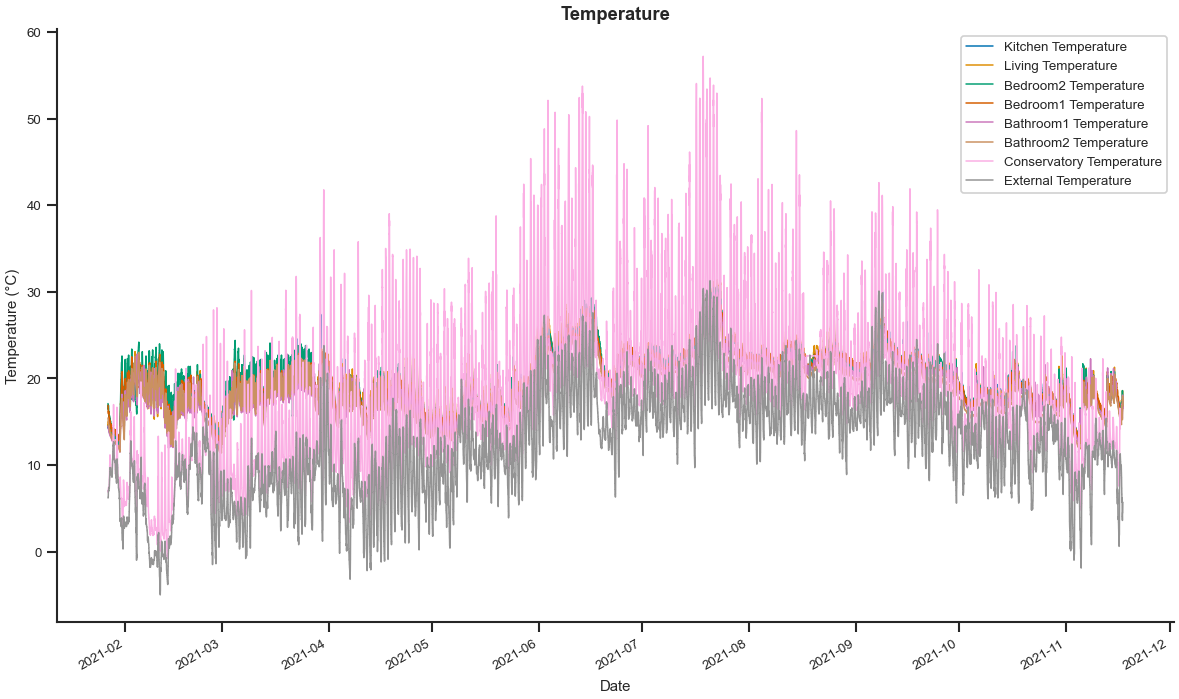

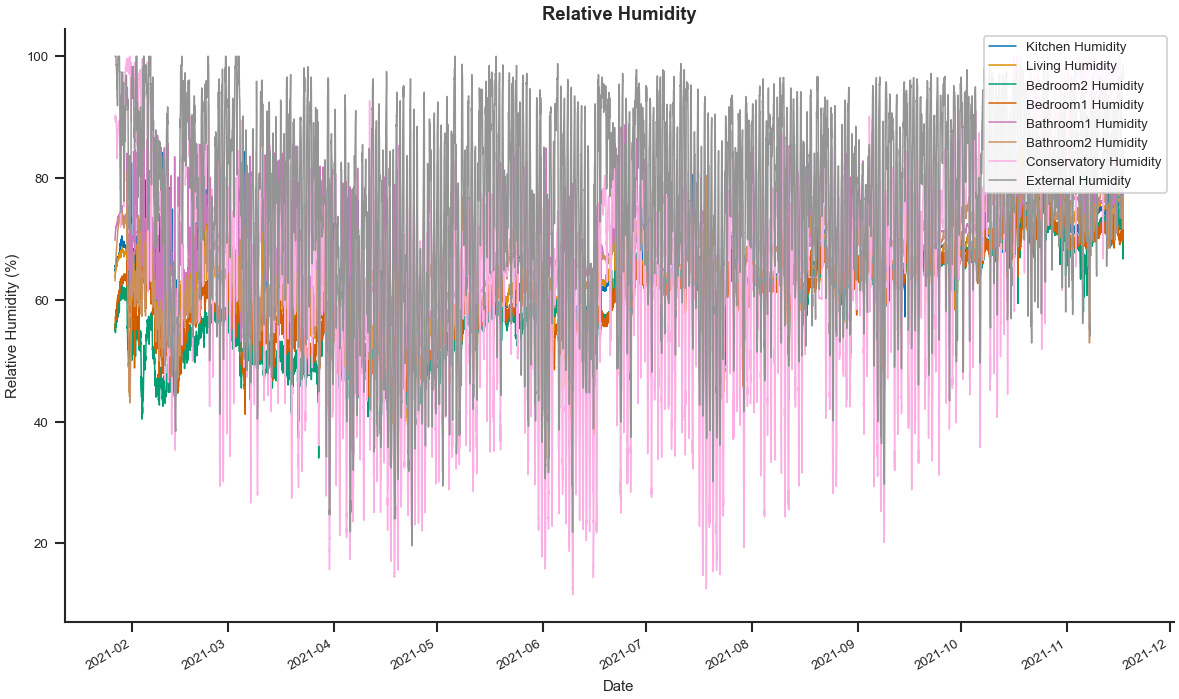

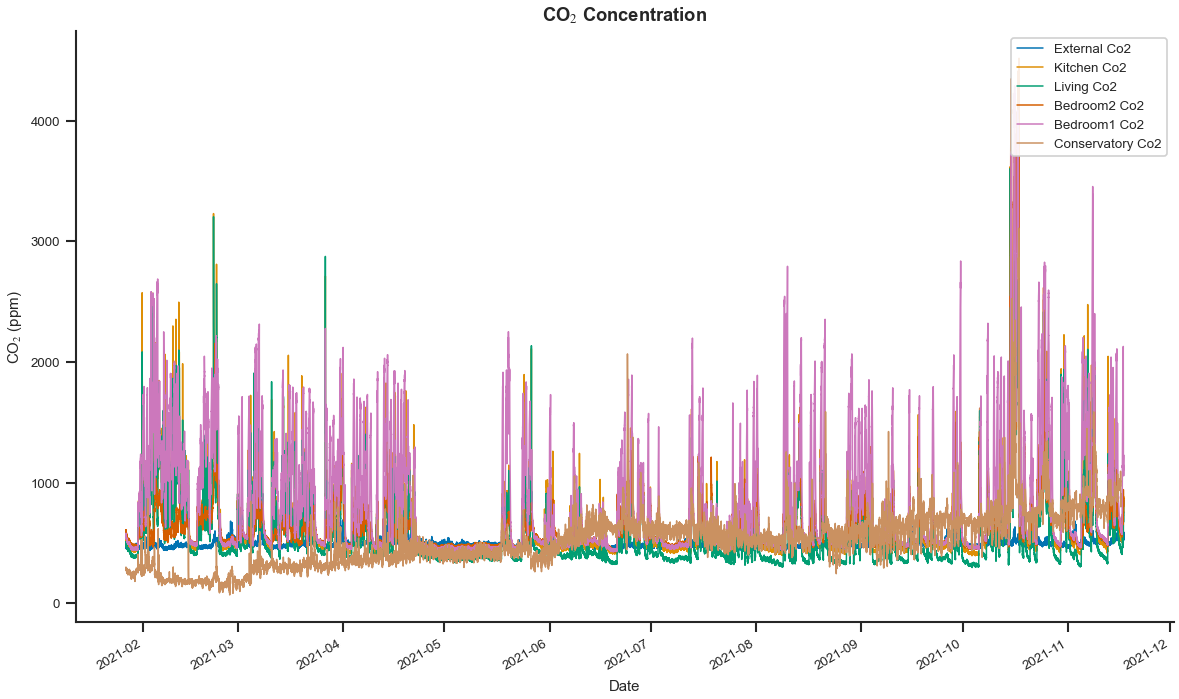

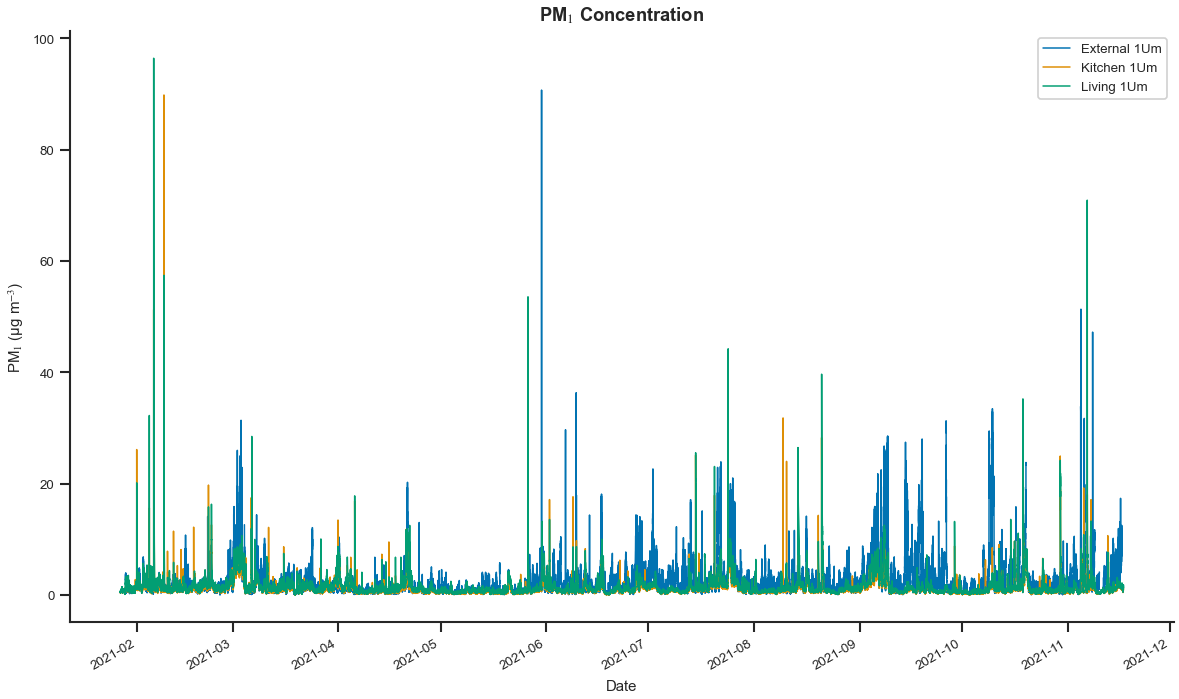

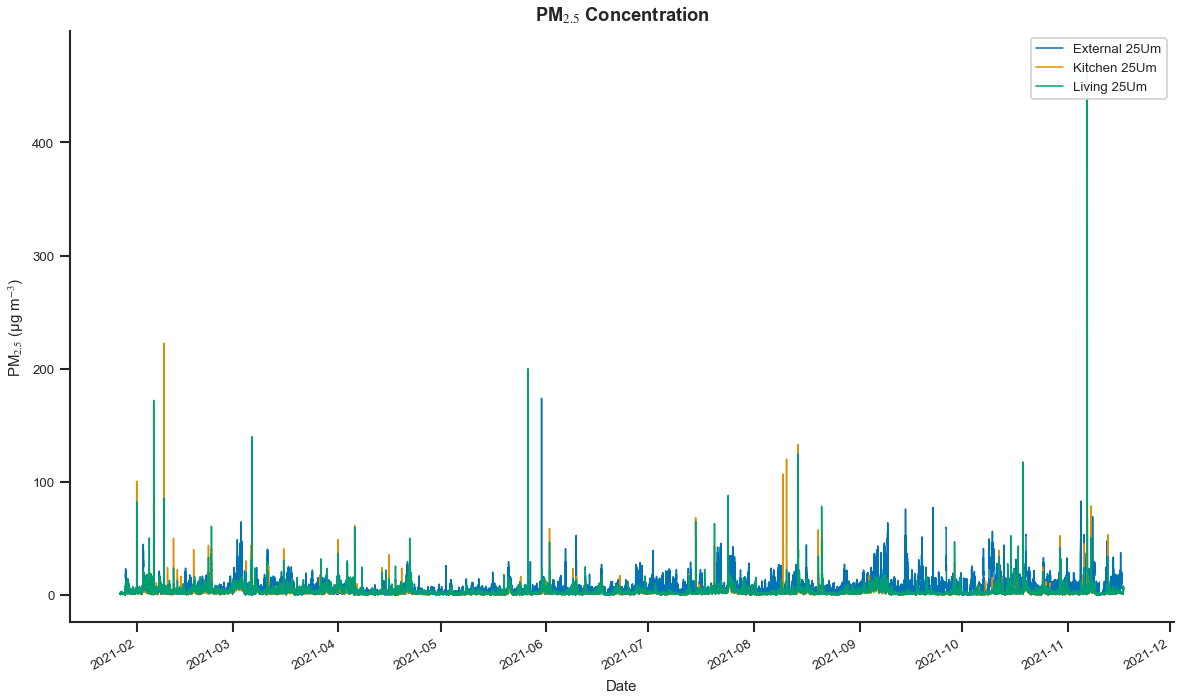

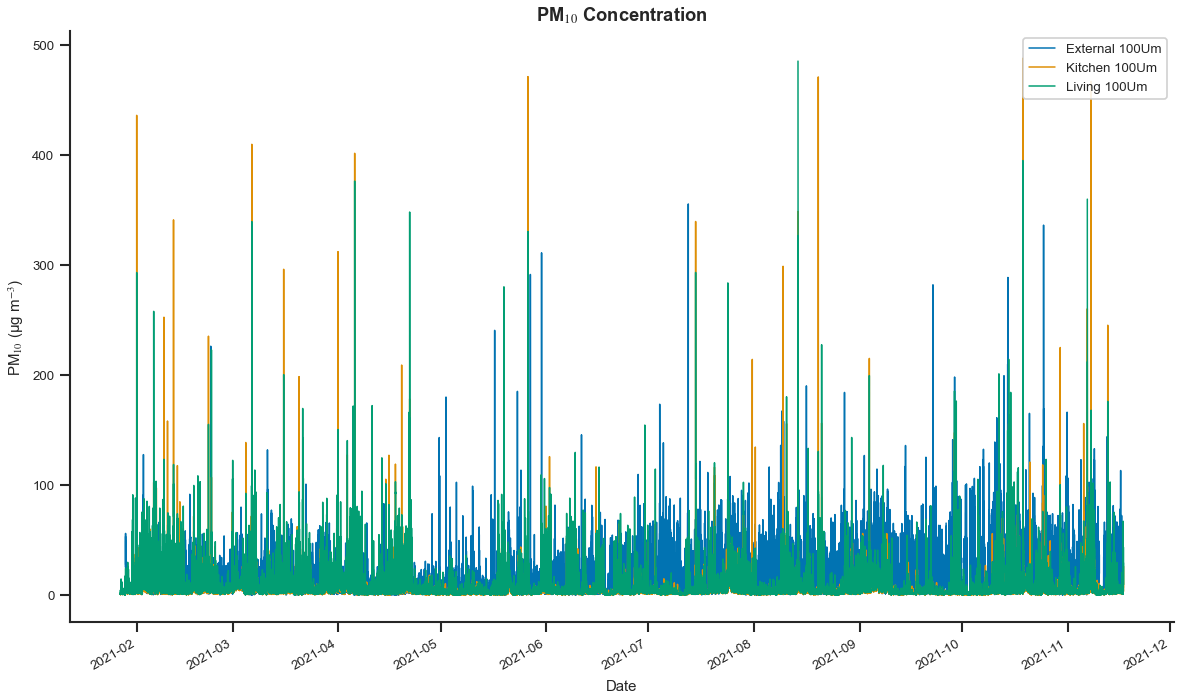

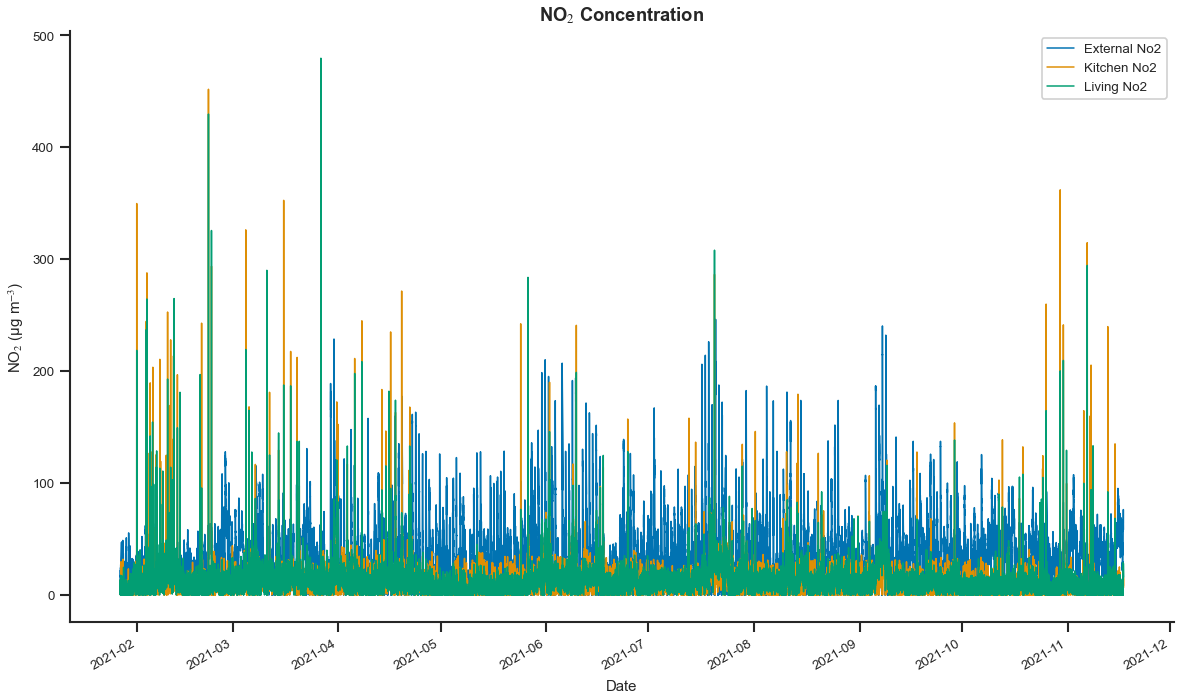

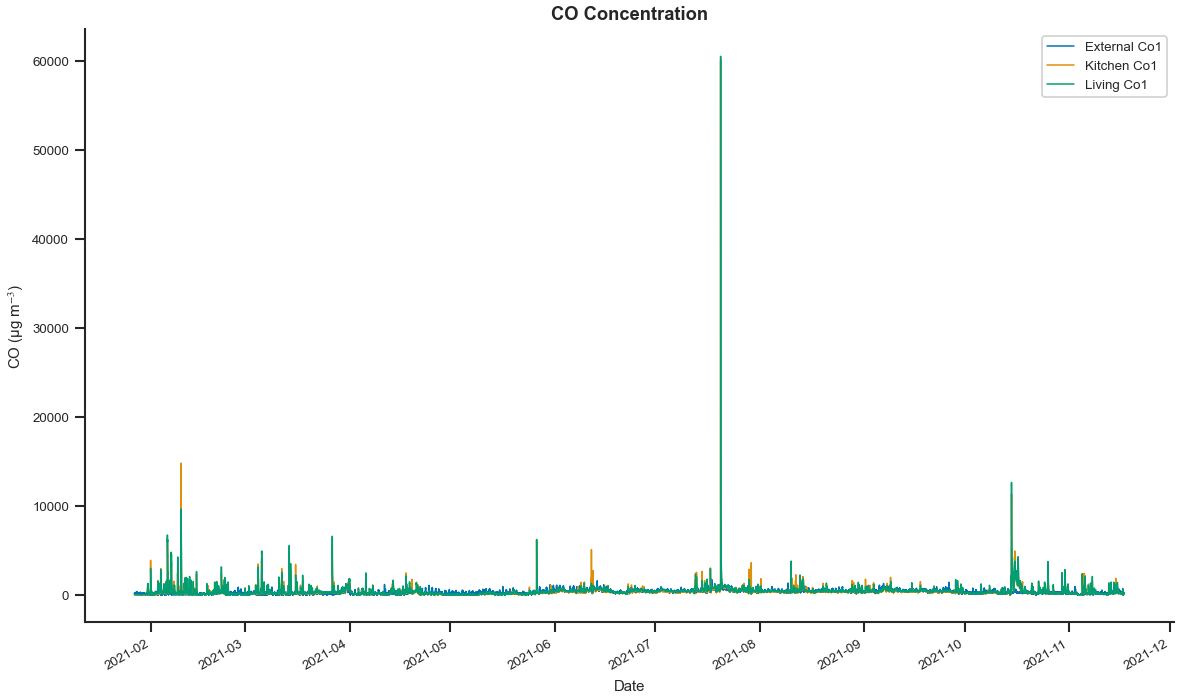

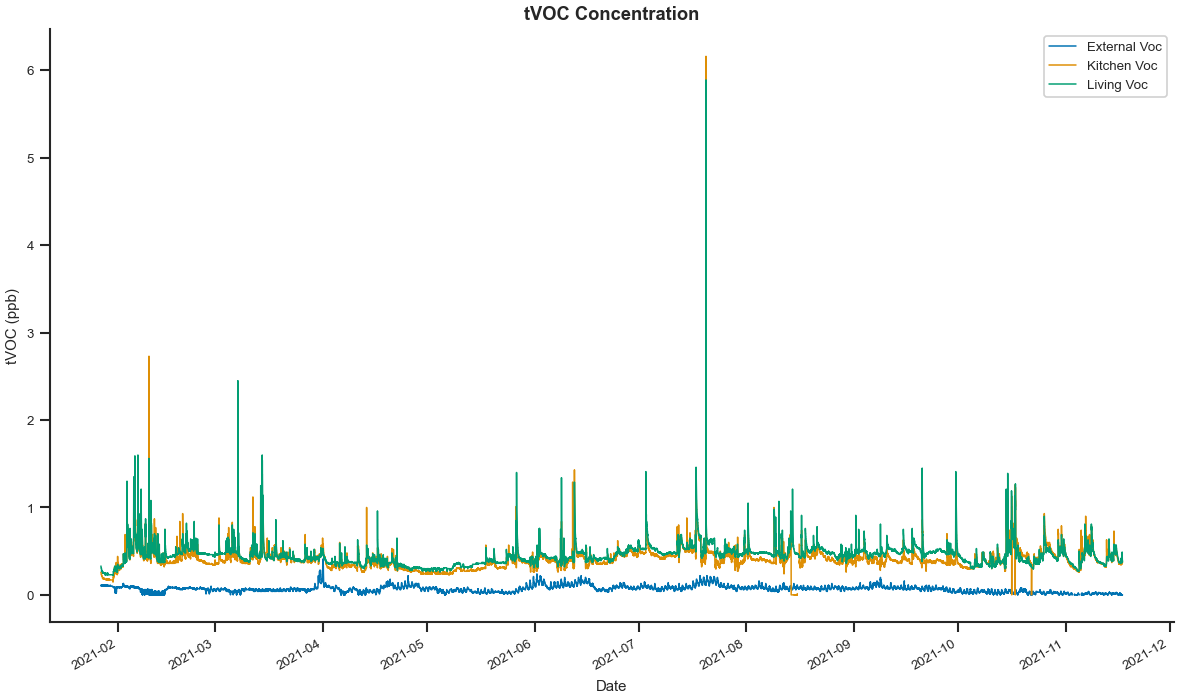

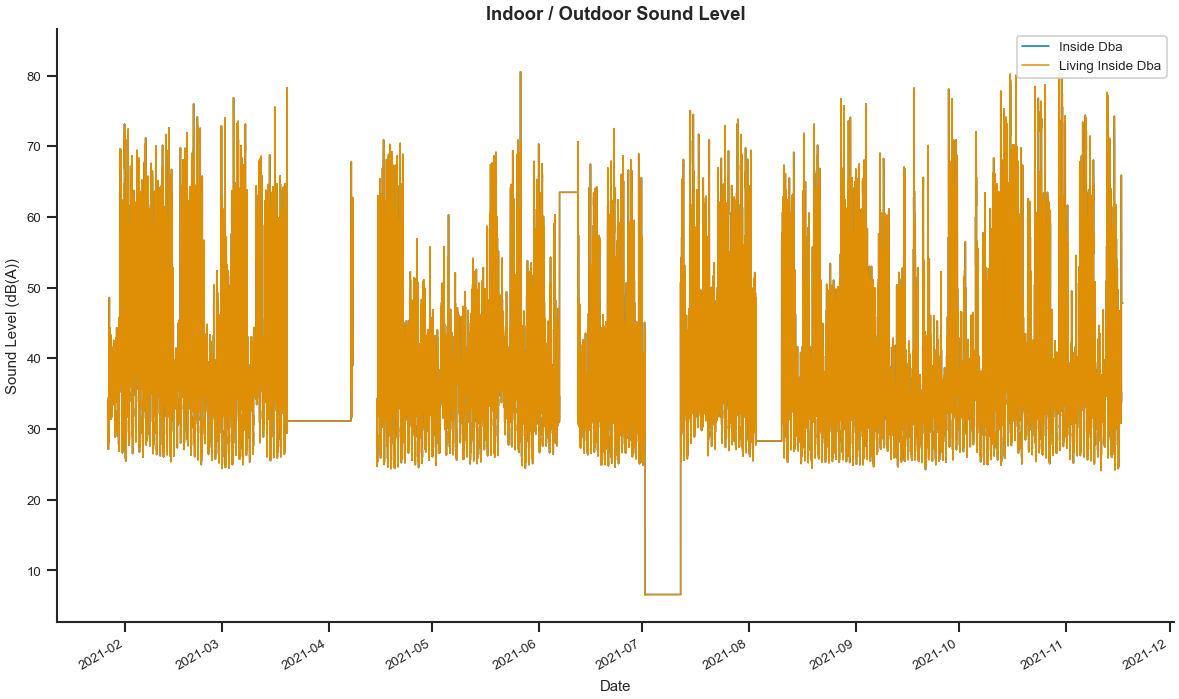

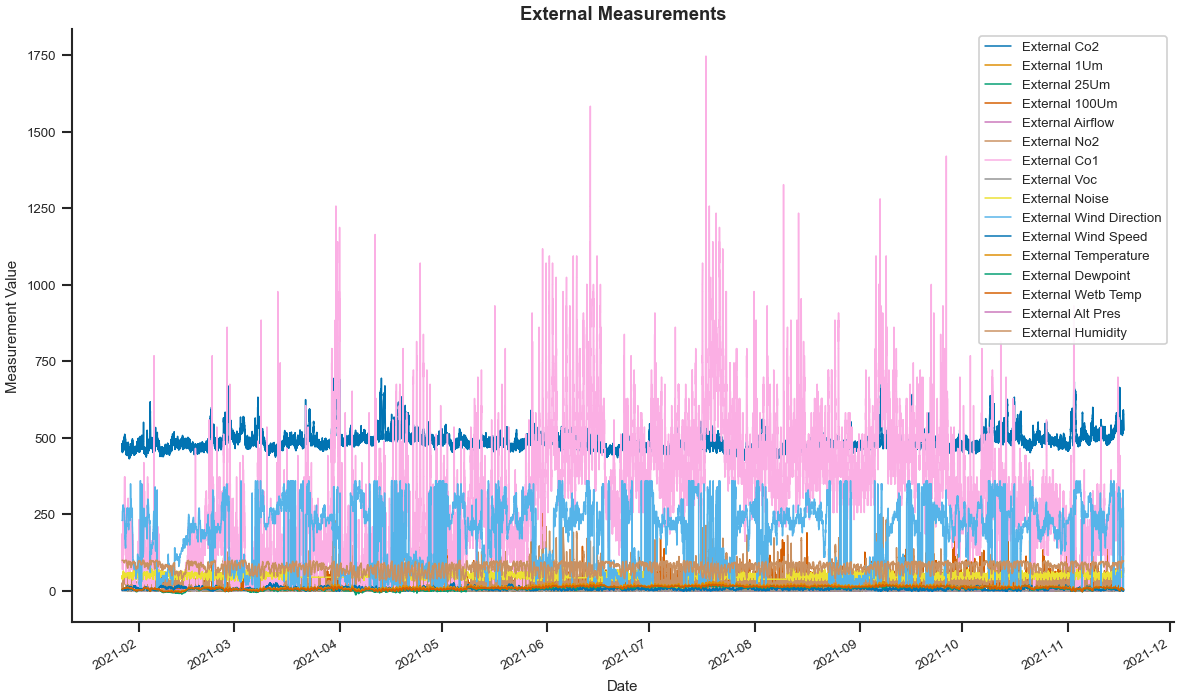

In [19]:
plot_grouped_variables(input_dataframe=p4, input_save=True, save_path="../data/p4_west_london_bungalow/plots/", figsize=(10, 6), dpi=300)

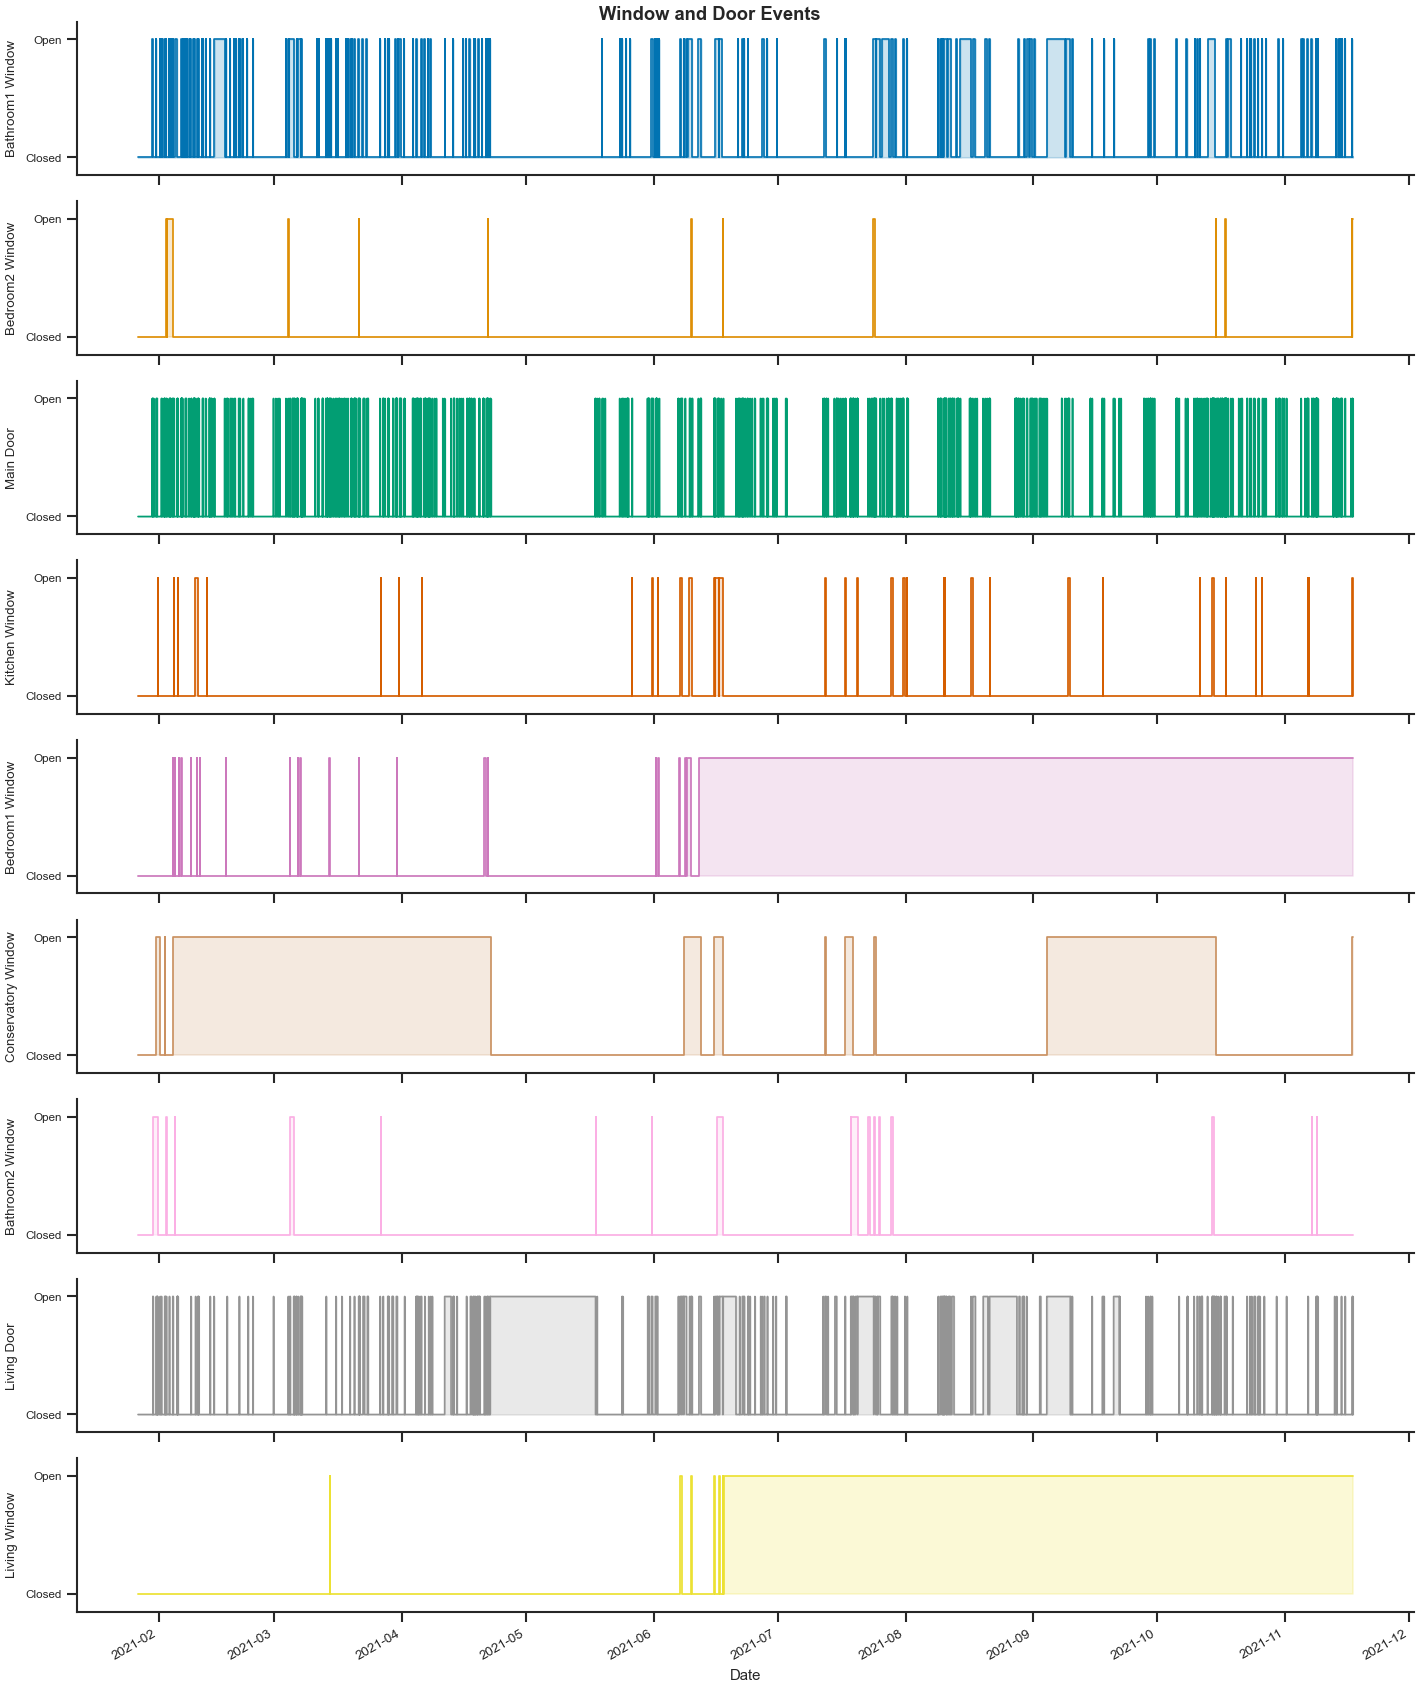

In [20]:
plot_event_timeseries(input_event_dict=p4_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p4_west_london_bungalow/plots/')

## Summary Statistics

In [21]:
p4_continuous_stats, p4_event_stats = summary_statistics(
    input_dataframe=p4,
    input_rooms_and_variables=p4_rooms_and_variables,
    input_event_dict=p4_event_dict,
    input_rooms_and_events=p4_rooms_and_events
)

# Print the number of days of data collected
num_days = (p4.index[-1] - p4.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  kitchen_temperature: n=84792, n_missing=0, mean=19.97, median=19.4
  kitchen_humidity: n=84792, n_missing=0, mean=63.604, median=64.0
  kitchen_co2: n=84792, n_missing=0, mean=634.027, median=521.0
  kitchen_1um: n=84792, n_missing=0, mean=1.149, median=0.76
  kitchen_25um: n=84792, n_missing=0, mean=2.144, median=1.4
  kitchen_100um: n=84792, n_missing=0, mean=3.962, median=1.78
  kitchen_airflow: n=84792, n_missing=0, mean=5.968, median=5.96
  kitchen_no2: n=84792, n_missing=0, mean=11.082, median=8.797
  kitchen_co1: n=84792, n_missing=0, mean=341.565, median=279.408
  kitchen_voc: n=84499, n_missing=293, mean=0.404, median=0.39
  conservatory_temperature: n=84579, n_missing=213, mean=18.415, median=17.534
  conservatory_humidity: n=84579, n_missing=213, mean=67.08, median=69.775
  conservatory_co2: n=84579, n_missing=213, mean=520.926, median=520.0
  external_co2: n=84789, n_missing=3, mean=490.052, median=484.0
 

## Save outputs

In [22]:
save_participant_outputs(
    n=4,
    df=p4,
    event_dict=p4_event_dict,
    rooms_and_variables=p4_rooms_and_variables,
    rooms_and_events=p4_rooms_and_events,
    rooms_list=p4_rooms_list,
    continuous_stats=p4_continuous_stats,
    event_stats=p4_event_stats,
data_dir='../data/p4_west_london_bungalow')

p4 outputs saved to ../data/p4_west_london_bungalow/data_processed/p4_outputs.pkl
